# 11 — Localised-bump stress test

The smooth-smile experiment in Stage 10 favoured SSVI–Dupire. That was an
important result because the true surface was close to the low-dimensional
shapes SSVI represents well.

This stage tests a different structural question:

> Can the methods recover a volatility feature that is localised in both
> log-moneyness and maturity?

The bump surface used here was already defined in Stage 3, before SSVI was
introduced. It is therefore not a new surface invented after seeing the Stage
10 result.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)


Project root: C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.synthetic_data import (
    generate_synthetic_option_data,
    save_synthetic_option_data,
)
from src.evaluation.benchmark import (
    compare_methods_on_quote_grid,
    repeated_noise_benchmark,
)
from src.evaluation.stress_tests import (
    localized_feature_metrics,
    repeated_noise_summary,
)
from src.evaluation.tuning import (
    linearized_lambda_sweep,
    select_lambda_by_gcv,
)
from src.inverse.linearized_inverse import (
    finite_difference_jacobian,
    price_quotes_from_log_variance,
    quote_weights,
)
from src.inverse.nonlinear_inverse import (
    run_gauss_newton_calibration,
)
from src.inverse.parameterization import (
    local_volatility_from_log_variance,
    reference_log_variance_surface,
)
from src.regularization.potentials import (
    combine_potentials,
    confidence_potential,
    quote_confidence_surface,
    wing_potential,
)
from src.regularization.scaling import (
    build_nondimensional_regularization_matrix,
)
from src.surfaces.synthetic_surfaces import (
    bump_surface,
)


## 1. Generate the Stage 3 bump market

The true surface is

$$
\sigma_{\mathrm{true}}(x,T)
=
0.20
+
0.05
\exp\left[
-\frac12
\left(\frac{x}{0.12}\right)^2
-\frac12
\left(\frac{T-0.60}{0.25}\right)^2
\right].
$$

It contains a localised feature rather than a global parametric smile.


In [3]:
bump_data_path = (
    project_root
    / "data"
    / "synthetic"
    / "bump_quotes.csv"
)

if bump_data_path.exists():
    bump_quotes = pd.read_csv(bump_data_path)
    print("Loaded:", bump_data_path)
else:
    bump_quotes = generate_synthetic_option_data(
        surface_function=bump_surface,
        spot=100.0,
        relative_noise=0.005,
        minimum_noise=0.01,
        random_seed=2468,
        number_of_strike_points=201,
        number_of_time_steps=160,
    )
    save_synthetic_option_data(
        bump_quotes,
        bump_data_path,
    )
    print("Generated and saved:", bump_data_path)

print("Number of quotes:", len(bump_quotes))


Generated and saved: C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\data\synthetic\bump_quotes.csv
Number of quotes: 78


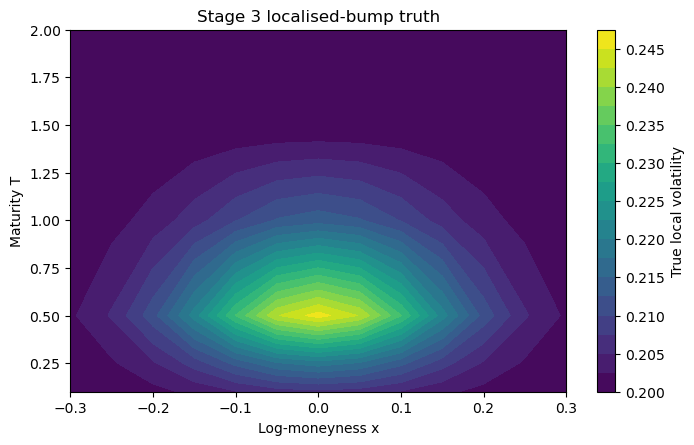

In [4]:
truth_matrix = bump_quotes.pivot(
    index="maturity",
    columns="log_moneyness",
    values="true_local_volatility",
)

plt.figure(figsize=(8, 4.7))
contour = plt.contourf(
    truth_matrix.columns.to_numpy(),
    truth_matrix.index.to_numpy(),
    truth_matrix.to_numpy(),
    levels=20,
)
plt.colorbar(contour, label="True local volatility")
plt.xlabel("Log-moneyness x")
plt.ylabel("Maturity T")
plt.title("Stage 3 localised-bump truth")
plt.show()


## 2. Keep the operator-model specification fixed

To avoid adapting the method specifically to the bump:

- the calibration grid remains the same $$(5\times9)$$ grid used in Stages 8–10;
- $$(\alpha_x=0.005)$$, $$(\alpha_T=0.002)$$, and $$(\beta=10^{-4})$$ are unchanged;
- the wing and confidence-potential settings are unchanged;
- only the global $$(\lambda)$$ is reselected by GCV because this is a new
  dataset.


In [5]:
spot = 100.0

calibration_T = np.linspace(
    0.10,
    2.00,
    5,
)
calibration_x = np.linspace(
    -0.35,
    0.35,
    9,
)

reference_log_variance = reference_log_variance_surface(
    maturities=calibration_T,
    log_moneyness=calibration_x,
    reference_volatility=0.20,
)

wing = wing_potential(
    log_moneyness=calibration_x,
    maturities=calibration_T,
    strength=0.20,
    power=2.0,
    start=0.20,
)

confidence = quote_confidence_surface(
    log_moneyness=calibration_x,
    maturities=calibration_T,
    quote_log_moneyness=bump_quotes[
        "log_moneyness"
    ].to_numpy(),
    quote_maturities=bump_quotes[
        "maturity"
    ].to_numpy(),
    log_moneyness_bandwidth=0.09,
    maturity_bandwidth=0.30,
)

confidence_penalty = confidence_potential(
    confidence=confidence,
    strength=0.20,
)

combined_potential = combine_potentials(
    wing,
    confidence_penalty,
)

regularization_matrix, _, _, scale_information = (
    build_nondimensional_regularization_matrix(
        maturities=calibration_T,
        log_moneyness=calibration_x,
        alpha_x=0.005,
        alpha_T=0.002,
        beta=1e-4,
        potential=combined_potential,
    )
)

print("Unknowns:", reference_log_variance.size)
print("Scaled R shape:", regularization_matrix.shape)
print("Unit-square cell area:", scale_information["cell_area"])


Unknowns: 45
Scaled R shape: (45, 45)
Unit-square cell area: 0.03125000000000001


## 3. Build the reference Jacobian and select \(\lambda\)

As before, GCV selects the amount of global regularisation from observable
price data. The known true surface is not used to select \(\lambda\).


In [6]:
reference_prices, reference_jacobian = (
    finite_difference_jacobian(
        reference_log_variance=reference_log_variance,
        calibration_maturities=calibration_T,
        calibration_log_moneyness=calibration_x,
        quote_data=bump_quotes,
        spot=spot,
        finite_difference_step=1e-3,
        scheme="forward",
        number_of_strike_points=151,
        number_of_time_steps=120,
        verbose=True,
    )
)

weights = quote_weights(
    bump_quotes,
    noise_column="noise_standard_deviation",
)
observed_prices = bump_quotes[
    "observed_call_price"
].to_numpy()
reference_residual = (
    observed_prices - reference_prices
)

lambda_values = np.logspace(
    -1,
    5,
    13,
)

lambda_results, lambda_solutions = (
    linearized_lambda_sweep(
        jacobian=reference_jacobian,
        residual=reference_residual,
        weights=weights,
        regularization_matrix=regularization_matrix,
        lambda_values=lambda_values,
    )
)

selected_lambda = select_lambda_by_gcv(
    lambda_results
)

print("GCV-selected lambda:", selected_lambda)
lambda_results


Jacobian columns completed: 4/45
Jacobian columns completed: 8/45
Jacobian columns completed: 12/45
Jacobian columns completed: 16/45
Jacobian columns completed: 20/45
Jacobian columns completed: 24/45
Jacobian columns completed: 28/45
Jacobian columns completed: 32/45
Jacobian columns completed: 36/45
Jacobian columns completed: 40/45
Jacobian columns completed: 44/45
Jacobian columns completed: 45/45
GCV-selected lambda: 10000.0


,lambda,weighted_data_misfit,weighted_rmse,regularization_penalty,objective,effective_degrees_of_freedom,gcv,correction_norm
0,0.100000,30.252676,0.622780,3.246122,30.577288,42.807709,1.905300,12.605662
1,0.316228,30.514264,0.625467,1.777924,31.076493,41.690577,1.805339,9.032817
2,1.000000,30.987963,0.630303,0.940875,31.928838,40.313364,1.701817,6.429118
3,3.162278,31.871202,0.639222,0.442108,33.269270,38.610017,1.602218,4.451625
4,10.000000,33.124977,0.651674,0.212123,35.246207,36.369078,1.490796,3.159232
5,31.622777,35.009422,0.669954,0.106139,38.365822,33.379446,1.371544,2.319316
6,100.000000,38.375480,0.701422,0.045923,42.967739,29.619027,1.278790,1.674479
7,316.227766,43.162836,0.743888,0.018089,48.883009,25.309880,1.212680,1.238647
8,1000.000000,48.791193,0.790903,0.007638,56.428773,20.790545,1.162788,1.011632
9,3162.277660,54.583840,0.836536,0.004172,67.777001,16.453337,1.123957,0.924006


## 4. Refine the operator-regularised estimate nonlinearly

The GCV-selected linearised correction supplies the starting surface. The full
PDE objective is then refined by damped Gauss–Newton.


In [7]:
initial_correction = lambda_solutions[
    float(selected_lambda)
].reshape(
    reference_log_variance.shape,
    order="C",
)

initial_log_variance = (
    reference_log_variance
    + initial_correction
)

operator_result = run_gauss_newton_calibration(
    reference_log_variance=reference_log_variance,
    initial_log_variance=initial_log_variance,
    calibration_maturities=calibration_T,
    calibration_log_moneyness=calibration_x,
    quote_data=bump_quotes,
    regularization_matrix=regularization_matrix,
    regularization_strength=selected_lambda,
    spot=spot,
    finite_difference_step=1e-3,
    jacobian_scheme="forward",
    number_of_strike_points=151,
    number_of_time_steps=120,
    maximum_iterations=4,
    initial_damping=1e-2,
    maximum_absolute_step=1.0,
    relative_objective_tolerance=1e-4,
    relative_step_tolerance=1e-3,
    verbose=True,
)

operator_volatility = (
    local_volatility_from_log_variance(
        operator_result[
            "estimated_log_variance"
        ]
    )
)

print("\nStop reason:", operator_result["stop_reason"])
print(
    "Final weighted price RMSE:",
    f"{operator_result['final_weighted_rmse']:.6f}",
)


Jacobian columns completed: 4/45
Jacobian columns completed: 8/45
Jacobian columns completed: 12/45
Jacobian columns completed: 16/45
Jacobian columns completed: 20/45
Jacobian columns completed: 24/45
Jacobian columns completed: 28/45
Jacobian columns completed: 32/45
Jacobian columns completed: 36/45
Jacobian columns completed: 40/45
Jacobian columns completed: 44/45
Jacobian columns completed: 45/45
Iteration 1: objective=88.891457, weighted RMSE=0.876716, step scale=1.0000, damping=1.000e-02
Jacobian columns completed: 4/45
Jacobian columns completed: 8/45
Jacobian columns completed: 12/45
Jacobian columns completed: 16/45
Jacobian columns completed: 20/45
Jacobian columns completed: 24/45
Jacobian columns completed: 28/45
Jacobian columns completed: 32/45
Jacobian columns completed: 36/45
Jacobian columns completed: 40/45
Jacobian columns completed: 44/45
Jacobian columns completed: 45/45
Iteration 2: objective=88.882326, weighted RMSE=0.876882, step scale=1.0000, damping=3.000e-0

## 5. Compare all reconstruction methods

The primary table uses one shared validity mask, so every method is scored on
the same quote-grid points.


In [8]:
comparison_table, pointwise_results, metadata = (
    compare_methods_on_quote_grid(
        quote_data=bump_quotes,
        regularized_maturities=calibration_T,
        regularized_log_moneyness=calibration_x,
        regularized_volatility_surface=operator_volatility,
        spot=spot,
        reference_volatility=0.20,
    )
)

comparison_table


,number_of_evaluation_points,rmse,mae,maximum_absolute_error,bias,method,method_valid_fraction
0,71,0.003102,0.002448,0.007948,0.000718,operator_regularized,1.000000
1,71,0.009953,0.007458,0.028126,0.004539,ssvi_dupire,1.000000
2,71,0.012764,0.007118,0.046156,-0.007118,constant_reference,1.000000
3,71,0.023356,0.016709,0.074432,-0.004684,smoothed_dupire,0.935897
4,71,0.029722,0.019775,0.101530,-0.002621,raw_dupire,0.935897


In [9]:
operator_rmse = float(
    comparison_table.loc[
        comparison_table["method"]
        == "operator_regularized",
        "rmse",
    ].iloc[0]
)
ssvi_rmse = float(
    comparison_table.loc[
        comparison_table["method"]
        == "ssvi_dupire",
        "rmse",
    ].iloc[0]
)

print(
    "Shared evaluation points:",
    int(pointwise_results["shared_valid"].sum()),
    "out of",
    len(pointwise_results),
)
print(
    "Operator RMSE:",
    f"{operator_rmse:.6f}",
)
print(
    "SSVI-Dupire RMSE:",
    f"{ssvi_rmse:.6f}",
)
print(
    "Operator improvement over SSVI:",
    f"{ssvi_rmse / operator_rmse:.2f}x lower RMSE",
)


Shared evaluation points: 71 out of 78
Operator RMSE: 0.003102
SSVI-Dupire RMSE: 0.009953
Operator improvement over SSVI: 3.21x lower RMSE


## 6. Did each method recover the bump itself?

Overall RMSE can hide whether the localised feature was placed correctly.

We therefore also measure:

- RMSE inside the bump region;
- RMSE outside the bump region;
- recovered peak height;
- recovered peak location;
- ratio of recovered to true excess peak volatility.


In [10]:
feature_table = localized_feature_metrics(
    pointwise_results=pointwise_results,
    method_columns=[
        "constant_reference",
        "raw_dupire",
        "smoothed_dupire",
        "ssvi_dupire",
        "operator_regularized",
    ],
)

feature_table


,method,overall_rmse,overall_mae,bump_region_rmse,outside_region_rmse,true_peak_volatility,estimated_peak_volatility,peak_amplitude_error,peak_excess_ratio,true_peak_x,estimated_peak_x,true_peak_maturity,estimated_peak_maturity,scaled_peak_location_error
0,operator_regularized,0.003102,0.002448,0.002703,0.003265,0.246156,0.246044,-0.000112,0.997574,0.0,0.00,0.5,0.5,0.000000
1,ssvi_dupire,0.009953,0.007458,0.010090,0.009891,0.246156,0.232133,-0.014023,0.696177,0.0,-0.25,0.5,0.5,2.083333
2,constant_reference,0.012764,0.007118,0.022561,0.002744,0.246156,0.200000,-0.046156,0.000000,0.0,NaN,0.5,NaN,NaN
3,smoothed_dupire,0.023356,0.016709,0.013904,0.026526,0.246156,0.255045,0.008889,1.192595,0.0,-0.15,0.5,0.1,2.030394
4,raw_dupire,0.029722,0.019775,0.013291,0.034652,0.246156,0.283221,0.037065,1.803049,0.0,-0.20,0.5,1.0,2.603417


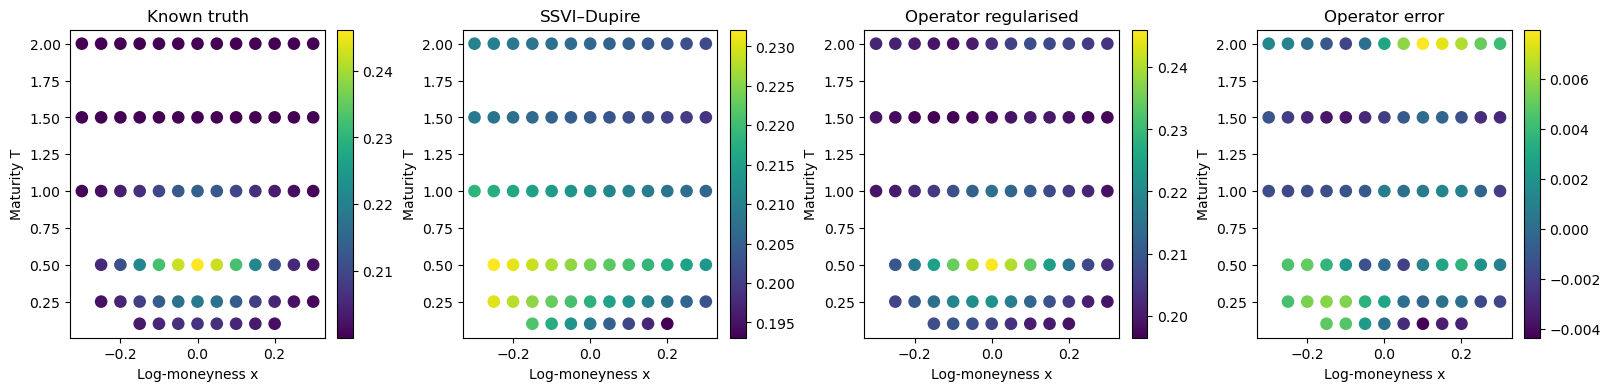

In [11]:
shared_points = pointwise_results[
    pointwise_results["shared_valid"]
].copy()

figure, axes = plt.subplots(
    1,
    4,
    figsize=(16, 3.8),
    constrained_layout=True,
)

plot_columns = [
    (
        "true_local_volatility",
        "Known truth",
    ),
    (
        "ssvi_dupire",
        "SSVI–Dupire",
    ),
    (
        "operator_regularized",
        "Operator regularised",
    ),
    (
        "operator_regularized",
        "Operator error",
    ),
]

for index, (
    axis,
    (column, title),
) in enumerate(zip(axes, plot_columns)):
    values = shared_points[column].to_numpy()
    if index == 3:
        values = (
            shared_points[
                "operator_regularized"
            ].to_numpy()
            - shared_points[
                "true_local_volatility"
            ].to_numpy()
        )

    scatter = axis.scatter(
        shared_points["log_moneyness"],
        shared_points["maturity"],
        c=values,
        s=65,
    )
    figure.colorbar(scatter, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("Log-moneyness x")
    axis.set_ylabel("Maturity T")

plt.show()


## 7. Repeat the comparison over ten noise realisations

For computational efficiency, the repeated-noise operator estimate uses the
same linearised inverse map, selected \(\lambda\), weights, and regulariser.
SSVI is refitted independently for every noise draw.


In [12]:
noise_results = repeated_noise_benchmark(
    clean_quote_data=bump_quotes,
    random_seeds=range(10),
    reference_prices=reference_prices,
    jacobian=reference_jacobian,
    weights=weights,
    reference_log_variance=reference_log_variance,
    calibration_maturities=calibration_T,
    calibration_log_moneyness=calibration_x,
    regularization_matrix=regularization_matrix,
    regularization_strength=selected_lambda,
    spot=spot,
)

robustness_summary = repeated_noise_summary(
    noise_results
)

robustness_summary


,method,mean_rmse,sd_rmse,minimum_rmse,maximum_rmse,mean_mae,mean_shared_valid_fraction
0,operator_regularized_linearized,0.003083,0.000532,0.002487,0.003930,0.002463,0.910256
1,ssvi_dupire,0.009814,0.000385,0.009406,0.010407,0.006908,0.910256
2,constant_reference,0.012767,0.000127,0.012590,0.012950,0.007140,0.910256
3,smoothed_dupire,0.037278,0.038980,0.019804,0.147791,0.019381,0.910256
4,raw_dupire,0.040973,0.008949,0.031437,0.059902,0.023982,0.910256


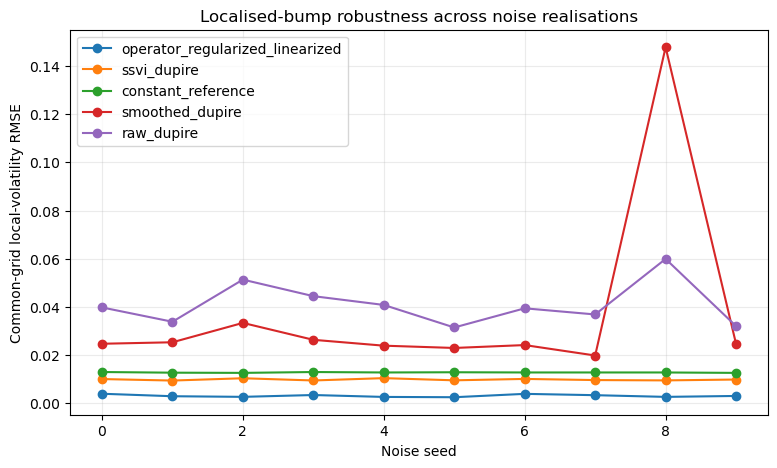

In [13]:
plt.figure(figsize=(9, 5.0))

for method in robustness_summary["method"]:
    method_data = noise_results[
        noise_results["method"] == method
    ]
    plt.plot(
        method_data["seed"],
        method_data["rmse"],
        marker="o",
        label=method,
    )

plt.xlabel("Noise seed")
plt.ylabel("Common-grid local-volatility RMSE")
plt.title("Localised-bump robustness across noise realisations")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8. Interpretation

Stages 10 and 11 should be read together:

- on the smooth smile, SSVI–Dupire was more accurate;
- on the pre-existing localised bump, the operator-regularised method is more
  accurate and recovers the peak more faithfully.

This supports a nuanced claim:

> SSVI is excellent when its low-dimensional shape is appropriate, whereas the
> operator method provides greater flexibility for localised structures while
> remaining stable under noisy prices.

Neither experiment establishes universal superiority.


## 9. Save Stage 11 outputs

In [14]:
output_directory = (
    project_root
    / "outputs"
    / "stage_11"
)
output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

comparison_path = (
    output_directory
    / "bump_common_grid_comparison.csv"
)
pointwise_path = (
    output_directory
    / "bump_common_grid_pointwise.csv"
)
feature_path = (
    output_directory
    / "bump_feature_metrics.csv"
)
lambda_path = (
    output_directory
    / "bump_lambda_sweep.csv"
)
noise_path = (
    output_directory
    / "bump_repeated_noise_results.csv"
)
summary_path = (
    output_directory
    / "bump_repeated_noise_summary.csv"
)
operator_path = (
    output_directory
    / "bump_operator_calibration.npz"
)

comparison_table.to_csv(
    comparison_path,
    index=False,
)
pointwise_results.to_csv(
    pointwise_path,
    index=False,
)
feature_table.to_csv(
    feature_path,
    index=False,
)
lambda_results.to_csv(
    lambda_path,
    index=False,
)
noise_results.to_csv(
    noise_path,
    index=False,
)
robustness_summary.to_csv(
    summary_path,
    index=False,
)

np.savez_compressed(
    operator_path,
    calibration_maturities=calibration_T,
    calibration_x=calibration_x,
    reference_log_variance=reference_log_variance,
    estimated_log_variance=operator_result[
        "estimated_log_variance"
    ],
    estimated_volatility=operator_volatility,
    selected_lambda=selected_lambda,
    reference_jacobian=reference_jacobian,
    weights=weights,
    fitted_prices=operator_result[
        "fitted_prices"
    ],
)

print(comparison_path)
print(pointwise_path)
print(feature_path)
print(lambda_path)
print(noise_path)
print(summary_path)
print(operator_path)


C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\outputs\stage_11\bump_common_grid_comparison.csv
C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\outputs\stage_11\bump_common_grid_pointwise.csv
C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\outputs\stage_11\bump_feature_metrics.csv
C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\outputs\stage_11\bump_lambda_sweep.csv
C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\outputs\stage_11\bump_repeated_noise_results.csv
C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\outputs\stage_11\bump_repeated_noise_summary.csv
C:\Users\Me\OneDrive\Desktop\Dupire_model\dupire_local_vol_project\outputs\stage_11\bump_operator_calibration.npz


## Stage 11 result

The synthetic validation now contains two complementary structures:

1. a global smooth smile that favours SSVI;
2. a localised bump that tests non-parametric flexibility.

This is a substantially stronger and more defensible comparison than reporting
only the synthetic case on which our method performs best.
